# Graph Engineering with OpenClaw on AMD Instinct: Multi-Agent Incident Triage

**Author**: Kalyan Archakam  
**Knowledge level**: Beginner

This tutorial shows how to build a multi-agent incident triage system that runs entirely on a single
AMD Instinct™ MI300X GPU using [OpenClaw](https://docs.openclaw.ai/) and [vLLM](https://docs.vllm.ai/).
You will serve a local Qwen3.6-35B-A3B model, configure a graph of three specialist agents, and run them
against real observability data from a microservices fault injection study.

## From prompt engineering to graph engineering

The way practitioners structure AI workloads has gone through several distinct stages:

**Prompt engineering**: a single model call, shaped by careful input text. The model is a black box; the lever is what you put in.

**Context engineering**: the model call is the same, but the surrounding context is curated:
retrieval-augmented generation, system prompts, tool descriptions, few-shot examples. Quality
of the context window determines quality of the output.

**Loop engineering**: a single agent runs a plan → act → observe cycle, retrying until a
termination condition is met. This is the default pattern for most AI coding agents today.

**Graph engineering**: the loop is replaced by an explicit graph. Multiple agents run in
parallel on different sub-problems; their outputs converge to a coordinator that makes a
decision. The structure between nodes (which agent sees which data, in what order) becomes
as important as the agents themselves.

The shift from loop to graph is not about adding complexity. It is about matching the structure
of the problem. Incident triage is naturally parallel: logs, metrics, and traces are independent
signals that can be read simultaneously. A loop processes them sequentially and asks one agent
to hold all three in context at once. A graph assigns each signal to a specialist and lets a
coordinator correlate the results: which is how an experienced SRE team actually works.

## What you'll build

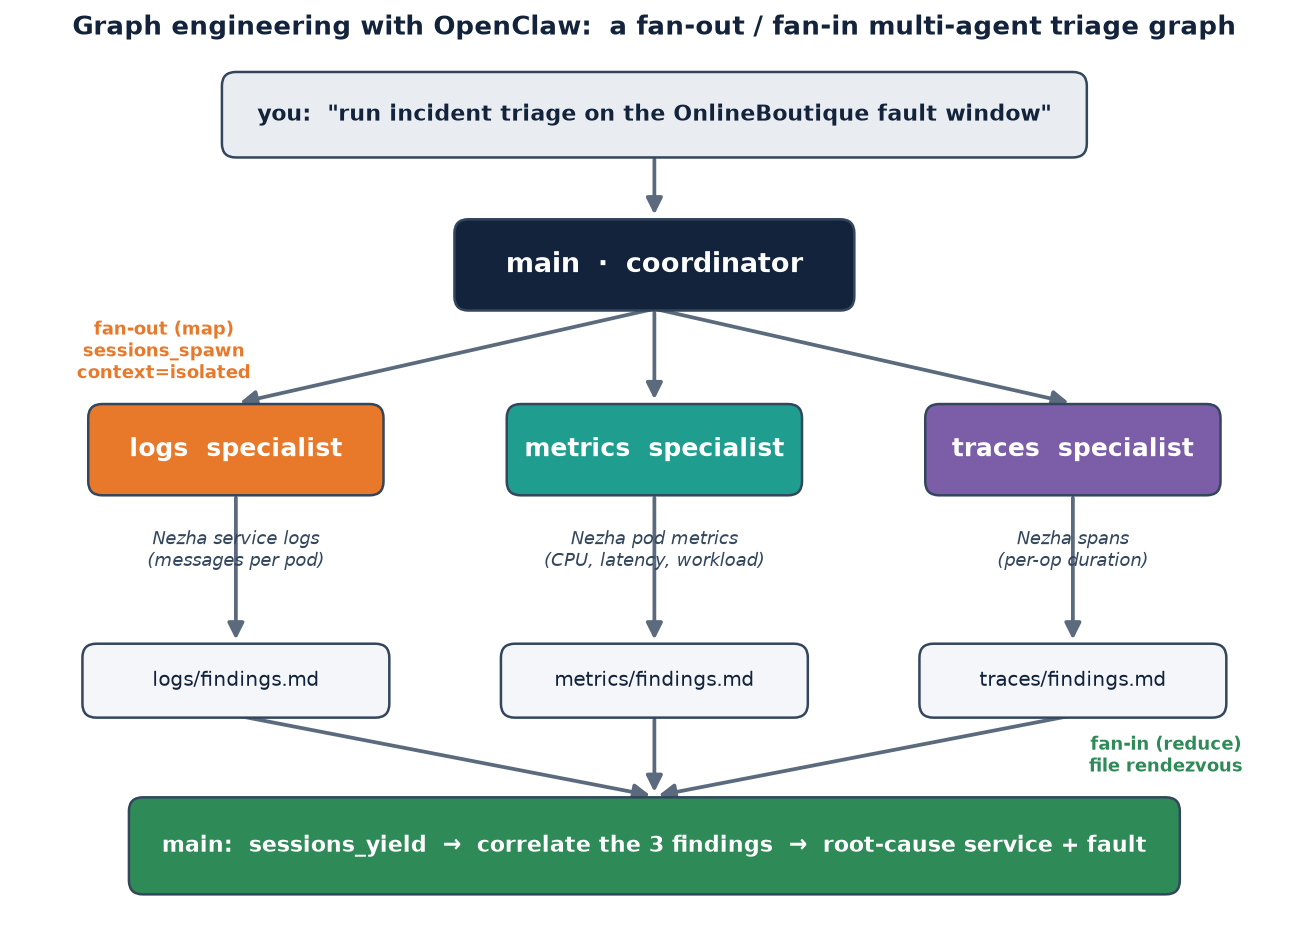

**How the graph maps onto OpenClaw:**

| Graph concept | OpenClaw primitive | Configured in |
|---|---|---|
| Nodes | `openclaw agents add`: one workspace per specialist | Part 5.1 |
| Typed edges | each agent's `AGENTS.md` briefing | Part 5.2 |
| Fan-out | `sessions_spawn` × 3, before the first yield | Part 5.4 |
| Fan-in | `sessions_yield` + per-agent `findings.md` | Part 5.4 |
| Adjacency list | `agents.defaults.subagents.allowAgents` | Part 5.3 |
| Bounded cycle | one-retry rule in the coordinator protocol | Part 5.4 |


## Prerequisites

This tutorial was developed and tested using the following setup.

### Operating system

Ubuntu 22.04 or 24.04.

### Hardware

**AMD Instinct GPUs**: This tutorial was tested on a single AMD Instinct MI300X GPU (192 GB HBM3). Ensure you are using an AMD Instinct GPU or compatible hardware with ROCm support and that your system meets the [official requirements](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/reference/system-requirements.html).

Consider using the AMD Developer Cloud to obtain access to these GPUs. See the **AMD Developer Cloud credits** section below.

You will need approximately **70 GB of free disk space** for the model weights.

### Software

**ROCm 7.0**: Install and verify ROCm by following the [ROCm install guide](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/install/quick-start.html). After installation, confirm your setup using:

```bash
amd-smi
```

This command lists your AMD GPUs with relevant details.

> **Note**: For ROCm 6.4 and earlier, use the `rocm-smi` command instead.

**Docker**: Ensure Docker is installed and configured correctly. Follow the [Docker installation guide](https://docs.docker.com/engine/install/) for your operating system.

> **Note**: Ensure Docker permissions are correctly configured. To allow non-root access, run:
>
> ```bash
> sudo usermod -aG docker $USER
> newgrp docker
> ```
>
> Verify Docker is working correctly:
>
> ```bash
> docker run hello-world
> ```

Confirm the GPU is visible on the host:

```bash
rocm-smi
```


## AMD Developer Cloud credits

The [AMD AI Developer Program](https://www.amd.com/en/developer/resources/ai-developer-program.html) provides members with $100 of free AMD Developer Cloud credits, enough for approximately 50 hours of usage.

> **Note**: Skip this section if you already have access to a droplet or have a local GPU.

To get started:

1. [Sign up for the AMD AI Developer Program](https://www.amd.com/en/developer/resources/ai-developer-program.html). Existing AMD account holders can sign in and enroll directly.

2. Activate your credits from the [AMD AI Developer Portal](https://developer.amd.com/) profile page.

3. Create a GPU Droplet by selecting a single Instinct MI300X instance with the ROCm software image and adding your SSH key.

4. After the droplet is created, connect to it via SSH:

   ```bash
   ssh root@<YOUR_DROPLET_IP>
   ```

Program members who publicly showcase and share useful applications or projects can also apply for additional credits.

## Part 0: Set up the environment

This tutorial uses two containers: one that serves the model, and one that runs JupyterLab
and OpenClaw. Both use `--network host` so they share the same localhost ports.

Put this notebook in your current directory before starting.

### 1. Start the vLLM server container (on the host)

`vllm/vllm-openai-rocm` has `vllm serve` as its entrypoint. Pass the model and flags directly
after the image name:

```bash
docker run -d --rm \
  --name vllm-server \
  --network host \
  --device /dev/kfd --device /dev/dri \
  --group-add video --ipc host \
  --security-opt seccomp=unconfined \
  -v $(pwd)/hf-cache:/root/.cache/huggingface \
  vllm/vllm-openai-rocm:latest \
  Qwen/Qwen3.6-35B-A3B \
  --served-model-name Qwen3.6-35B-A3B \
  --api-key abc-123 \
  --host 0.0.0.0 --port 8000 \
  --max-model-len 32768 \
  --enable-auto-tool-choice --tool-call-parser qwen3_xml \
  --reasoning-parser qwen3 \
  --trust-remote-code
```

`-v $(pwd)/hf-cache:/root/.cache/huggingface` caches the model weights on the host so they
persist across container restarts.

Check that the server started:

```bash
docker logs vllm-server 2>&1 | grep "Application startup complete"
```

### 2. Start the JupyterLab container (on the host)

Use `--entrypoint bash` to override the `vllm serve` entrypoint and get a shell:

```bash
docker run -it --rm \
  --name vllm-graph \
  --network host \
  --device /dev/kfd --device /dev/dri \
  --group-add video --ipc host \
  --security-opt seccomp=unconfined \
  --entrypoint bash \
  -v $(pwd):/workspace -w /workspace \
  -v $(pwd)/hf-cache:/root/.cache/huggingface \
  vllm/vllm-openai-rocm:latest
```

### 3. Launch JupyterLab (inside the vllm-graph shell)

```bash
pip install -q jupyterlab
jupyter lab --ip 0.0.0.0 --port 8888 --no-browser --allow-root
```

Open the printed `http://127.0.0.1:8888/lab?token=...` URL, then open this notebook. Steps
that say **🖥️ Jupyter terminal** use a terminal inside this container.

## Part 1 : Wait for the vLLM server

The server container started in Part 0 is downloading and loading the model. Run the cell
below to poll until it is ready. This typically takes 3-5 minutes on first run (weight
download) and under a minute on subsequent runs (weights already cached).

The vLLM image used is `vllm/vllm-openai-rocm:latest`, which is the official ROCm-enabled
vLLM image and includes support for the Qwen3.6 architecture (`Qwen3_5MoeForCausalLM`).
The `rocm/vllm` image used in other tutorials predates this architecture and does not
support it.

In [ ]:
import urllib.request, json

try:
    req = urllib.request.Request(
        "http://127.0.0.1:8000/v1/models",
        headers={"Authorization": "Bearer abc-123"},
    )
    data = json.load(urllib.request.urlopen(req, timeout=5))
    print("READY - vLLM is serving:", data["data"][0]["id"])
except Exception as e:
    print("NOT READY yet - wait for 'Application startup complete', then re-run this cell.")
    print("Details:", repr(e))

## Part 2: Install OpenClaw

OpenClaw runs your agents as a local service (the *gateway*). The installer adds Node.js and the
`openclaw` CLI to the container.

Open a 🖥️ **Jupyter terminal** (**Launcher → `+` → Terminal**) and run the installer there. It
starts a short interactive setup ("doctor") step that prompts for confirmation, so it needs a real
terminal and can't run from a notebook cell:

```bash
curl -fsSL --proto '=https' --tlsv1.2 https://openclaw.ai/install.sh | bash
```

Accept the recommended config repairs when prompted. When it finishes, come back here and run the
cell below to confirm the CLI is installed.

In [ ]:
!openclaw --version

## Part 3: Connect OpenClaw to the model and start the gateway

### 3.1 Onboard against the vLLM endpoint

The model id must match `--served-model-name`, and the api-key must match `--api-key` from Part 1.

In [ ]:
%%bash
openclaw onboard --non-interactive --mode local \
  --auth-choice custom-api-key \
  --custom-base-url "http://localhost:8000/v1" \
  --custom-model-id "Qwen3.6-35B-A3B" --custom-provider-id "vllm" \
  --custom-compatibility openai --custom-api-key "abc-123" \
  --secret-input-mode plaintext \
  --skip-channels --skip-search --skip-hooks --skip-ui --skip-health --accept-risk

### 3.2 Keep the full tool surface (lean mode off)

Leave **lean mode off** for this graph. Lean mode shrinks the tool surface and moves tools like
`sessions_spawn` / `sessions_yield` *behind* a `tool_search` step. A small local model often won't
discover them there, so the coordinator can't fan out and you'll see
`sessions_spawn tool is not available`. Keeping the full surface exposed lets `main` call the
spawn/yield tools directly.

In [ ]:
%%bash
openclaw config set agents.defaults.experimental.localModelLean false
echo "lean mode off (sessions_spawn/yield stay directly available)"

### 3.3 Start the gateway (background)

This container has no `systemd`, so run the gateway directly with `nohup`.

In [ ]:
%%bash
pkill -f openclaw-gateway 2>/dev/null || true
sleep 1
nohup openclaw gateway run > ~/gateway.log 2>&1 &
sleep 3
tail -n 8 ~/gateway.log

### 3.4 Smoke-test the model

In [ ]:
!openclaw agent --local --session-id smoke --message "Reply with exactly: pong" --thinking off

It should reply `pong`.


## Part 4: Fetch the incident data

This tutorial uses one fault window from the
[Nezha](https://github.com/IntelligentDDS/Nezha) observability dataset: real logs, metrics,
and traces captured from the **OnlineBoutique** microservices application during a controlled
fault injection experiment. A fault was injected into exactly one service; all three signals
carry a trace of it, but no single signal is sufficient to identify the culprit.

The raw per-minute CSV files are 4–15 MB each. The three cells below download and curate them
into compact, model-readable files in `/workspace/incident/`.

In [ ]:
import os, io, csv, json, urllib.request

NEZHA_DATE   = "2022-08-22"
FAULT_WINDOW = ["04:44", "04:45", "04:46"]   # fault injected at 04:44:16
BASELINE_MIN = "04_36"
FAULT_MIN    = "04_45"
INCIDENT_DIR = "/workspace/incident"
RAW = f"https://raw.githubusercontent.com/IntelligentDDS/Nezha/main/rca_data/{NEZHA_DATE}/"

PODS = [
    "adservice-5f6585d649-fnmft",        "cartservice-579f59597d-wc2lz",
    "checkoutservice-578fcf4766-9csqn",  "currencyservice-cf787dd48-vpjrd",
    "emailservice-55fdc5b988-f6xth",     "frontend-579b9bff58-t2dbm",
    "paymentservice-9cdb6588f-554sm",    "productcatalogservice-668d5f85fb-wckp8",
    "recommendationservice-6cfdd55578-gfj6q", "shippingservice-7b598fc7d-lmggd",
]
svc = lambda pod: pod.split("-")[0]
os.makedirs(INCIDENT_DIR, exist_ok=True)

def fetch(path):
    req = urllib.request.Request(RAW + path, headers={"User-Agent": "notebook"})
    return urllib.request.urlopen(req, timeout=180).read().decode("utf-8", "replace")

In [ ]:
# Metrics: CPU usage, server-latency P95, and workload for each service across the fault window.
rows = []
for pod in PODS:
    for r in csv.DictReader(io.StringIO(fetch(f"metric/{pod}_metric.csv"))):
        if r["Time"][11:16] in FAULT_WINDOW:
            rows.append([svc(pod), r["Time"][11:19],
                         round(float(r["CpuUsageRate(%)"]), 1),
                         round(float(r["PodServerLatencyP95(s)"]), 3),
                         round(float(r["PodWorkload(Ops)"]), 1)])
with open(f"{INCIDENT_DIR}/metrics.csv", "w") as f:
    f.write("service,time,cpu_usage_rate_pct,server_latency_p95_s,workload_ops\n")
    f.write("\n".join(",".join(map(str, r)) for r in rows) + "\n")
print(f"metrics.csv  {os.path.getsize(f'{INCIDENT_DIR}/metrics.csv')} bytes")

In [ ]:
# Traces: span-latency P95 per service: fault minute vs a baseline minute.
def p95(vals): return sorted(vals)[int(len(vals) * 0.95)] if vals else 0

def p95_by_svc(minute):
    d = {}
    for r in csv.DictReader(io.StringIO(fetch(f"trace/{minute}_trace.csv"))):
        d.setdefault(svc(r["PodName"]), []).append(int(r["Duration"]))
    return {s: p95(v) for s, v in d.items()}

base, fault = p95_by_svc(BASELINE_MIN), p95_by_svc(FAULT_MIN)
with open(f"{INCIDENT_DIR}/traces.csv", "w") as f:
    f.write("service,baseline_p95_ms,fault_p95_ms,slowdown_x\n")
    for s in sorted(set(base) | set(fault)):
        b, x = base.get(s, 0) / 1e6, fault.get(s, 0) / 1e6
        f.write(f"{s},{round(b,2)},{round(x,2)},{round(x/b,1) if b else 0}\n")
print(f"traces.csv   {os.path.getsize(f'{INCIDENT_DIR}/traces.csv')} bytes")

In [ ]:
# Logs: per-service line count, error/warning count, and one sample message.
counts, errors, sample = {}, {}, {}
for r in csv.DictReader(io.StringIO(fetch(f"log/{FAULT_MIN}_log.csv"))):
    s = svc(r["PodName"]); counts[s] = counts.get(s, 0) + 1
    if any(k in r["Log"].lower() for k in ('"error"','"warn"',"exception","failed","panic")):
        errors[s] = errors.get(s, 0) + 1
    if s not in sample:
        try:    sample[s] = json.loads(json.loads(r["Log"])["log"])["message"][:100]
        except: sample[s] = r["Log"][:100]
with open(f"{INCIDENT_DIR}/logs.txt", "w") as f:
    f.write(f"# OnlineBoutique logs: fault minute {FAULT_MIN.replace('_',':')}\n")
    f.write("# service: lines | errors/warnings | sample\n\n")
    for s in sorted(counts, key=lambda k: -counts[k]):
        f.write(f"{s}: {counts[s]} lines | {errors.get(s,0)} err/warn | {sample.get(s,'')}\n")
print(f"logs.txt     {os.path.getsize(f'{INCIDENT_DIR}/logs.txt')} bytes")

**Ground truth** (from Nezha's `fault_list.json`, for your reference: the agents must rediscover it):
At **04:44:16** a **CPU-contention** fault was injected into **`checkoutservice`**. It appears as CPU pinned near 100% and server-latency P95 jumping from ~0.24s to ~4.5s (metrics), and a ~6x span slowdown (traces). There are no error logs anywhere, which indicates a resource problem rather than a code bug. The high log volume on `productcatalogservice` is noise: that service is chatty but healthy. The graph has to correlate all three signals to identify `checkoutservice` rather than the noisiest service.

## What the data looks like

After the cells above run, `/workspace/incident/` contains three files. Each one is small enough
for a language model to read in full, but rich enough to require cross-signal reasoning.

**`metrics.csv`** records CPU usage rate (%), server-side latency P95 (seconds), and request
workload (ops/s) for all 10 services across the three-minute fault window:

```
service,time,cpu_usage_rate_pct,server_latency_p95_s,workload_ops
adservice,04:44:19,2.7,0.04,4.9
checkoutservice,04:44:19,7.6,0.242,0.4
checkoutservice,04:45:19,98.8,4.5,0.2
checkoutservice,04:46:19,100.8,4.625,0.3
frontend,04:45:19,25.2,0.935,7.9
...
```

**`traces.csv`** gives span-latency P95 per service for the fault minute compared to a baseline
minute captured 8 minutes earlier:

```
service,baseline_p95_ms,fault_p95_ms,slowdown_x
checkoutservice,0.3,1.8,5.9
frontend,0.22,0.18,0.8
productcatalogservice,0.01,0.01,1.0
...
```

**`logs.txt`** summarises log activity per service: line count, error/warning count, and one
sample message:

```
# OnlineBoutique logs - fault minute 04:45
# service: lines | errors/warnings | sample

productcatalogservice: 9964 lines | 0 err/warn | Query product with name and description successfully
currencyservice: 7383 lines | 0 err/warn | Get currency data successful
checkoutservice: 416 lines | 0 err/warn | PlaceOrder user_id="45bf39a9..." ...
paymentservice: 32 lines | 0 err/warn | Transaction processed: visa ending ...
```

A few things worth noting before running the graph:

- `productcatalogservice` generates the most log lines by a wide margin, but has zero errors.
- `checkoutservice` CPU is normal at 04:44 and pegged near 100% from 04:45 onward.
- The traces table shows a 5.9x slowdown for `checkoutservice`; every other service is near 1.0x.
- No service logs any errors or warnings during the fault window.

## Part 5: Configure the graph

This part defines the graph structure as OpenClaw configuration: which agents exist, what each
one knows, which tools the coordinator can call, and the control flow that wires them together.

### 5.1 Add the graph nodes

In a directed graph, a **node** is a unit of computation with its own state and a defined
interface. Each specialist agent is a node: it has an isolated workspace (its state), reads
exactly one signal (its input interface), and writes to a fixed `findings.md` file (its output
interface).

Keeping workspaces isolated enforces the typed-edge contract from 5.2. A node that can access every signal is not a specialist. It is a general-purpose agent running in a loop. The
isolation is what gives the graph its structure.

The three node identities: `logs`, `metrics`, `traces`: become the edge labels wired together
in 5.3.

In [ ]:
%%bash
for name in logs metrics traces; do
  openclaw agents add "$name" --non-interactive --workspace "/root/.openclaw/workspace/$name"
  rm -f "/root/.openclaw/workspace/$name/BOOTSTRAP.md"
done
openclaw agents list

### 5.2 Define the typed edges

In graph terminology, a **typed edge** carries a label that restricts what flows along it. Here the label is the agent's briefing: it specifies which signal the agent reads and what it ignores. Sending a different briefing changes the edge type; the graph rewires without touching any code.

You define each edge by sending the agent its briefing directly. The message you send becomes the agent's `AGENTS.md`: its persistent briefing, loaded
at the start of every session. Change the briefing and you change the edge.

Open a 🖥️ **Jupyter terminal** for each specialist below. The pattern is the same every time:

```bash
openclaw tui
```

Switch to the specialist with `/agent <name>`, then paste the briefing. The agent will write its
`AGENTS.md` and confirm. Type `/exit` when done, then move to the next one.

> **Important:** the briefing ends with "do not analyze anything now": you are configuring the
> agent, not running it yet. If you omit that line the agent may immediately try to read a file
> that does not exist yet.

---

#### logs specialist: `/agent logs`

```
You are the Logs Specialist for an incident-triage graph. Your job:
- When given a task, read ONLY the file /workspace/incident/logs.txt: a per-service log
  summary from the OnlineBoutique microservices system showing line counts, error/warning
  counts, and a sample message per service.
- Report: which services (if any) show error or warning lines, which is noisiest by volume,
  and whether the evidence points to a code bug or a resource issue. High volume alone is
  NOT a fault. Ignore metrics and traces.
- Save your findings to /root/.openclaw/workspace/logs/findings.md and reply concisely.

Save this as your AGENTS.md so it persists. Do not analyze anything now: wait for a task.
```

---

#### metrics specialist: `/agent metrics`

```
You are the Metrics Specialist for an incident-triage graph. Your job:
- When given a task, read ONLY the file /workspace/incident/metrics.csv: a cross-service
  table of CPU usage (%), server-latency P95 (s), and workload (ops) for a fault window in
  the OnlineBoutique system.
- Report: which service's CPU and/or latency deviates most from the rest, at what time, and
  which services look normal. Name the standout service clearly. Ignore logs and traces.
- Save your findings to /root/.openclaw/workspace/metrics/findings.md and reply concisely.

Save this as your AGENTS.md so it persists. Do not analyze anything now: wait for a task.
```

---

#### traces specialist: `/agent traces`

```
You are the Traces Specialist for an incident-triage graph. Your job:
- When given a task, read ONLY the file /workspace/incident/traces.csv: a per-service
  span-latency comparison table with baseline P95, fault-window P95, and a slowdown factor
  (x) for the OnlineBoutique system.
- Report: which service has the highest slowdown_x, which stayed near 1.0x, and what that
  pattern implies about where the fault is localised. Ignore logs and metrics.
- Save your findings to /root/.openclaw/workspace/traces/findings.md and reply concisely.

Save this as your AGENTS.md so it persists. Do not analyze anything now: wait for a task.
```

---

After all three confirm they've written their `AGENTS.md`, **run the 5.5 gateway-restart cell**.
`AGENTS.md` is loaded at session start, so the gateway must be fresh before the triage will use your new briefings.

### 5.3 Define the adjacency list

In a directed graph, the **adjacency list** records which nodes a given node has outgoing edges
to. `allowAgents` is that list for `main`: it specifies which agents the coordinator is
permitted to spawn. Agents not on the list cannot be reached: the graph topology is enforced by configuration, not by trust.

`tools.alsoAllow` adds the `sessions_spawn` and `sessions_yield` primitives to `main`'s tool
surface. Without them the coordinator has no mechanism to fan out or wait for results.

In [ ]:
%%bash
openclaw config set agents.defaults.subagents.allowAgents '["logs","metrics","traces"]' --strict-json
openclaw config set tools.alsoAllow '["sessions_spawn","sessions_yield","subagents"]' --strict-json
echo "main may now spawn: logs, metrics, traces"

### 5.4 Define the control flow

The coordinator protocol is the program that runs on the edges of the graph: which nodes to
activate (fan-out), when to wait for their outputs (fan-in), how to combine the results, and
what to do if they disagree (bounded retry). It is written as natural language appended to
`main`'s `AGENTS.md`: the same mechanism used for individual node briefings, applied to the
coordinator that owns the graph structure.

The cell is idempotent: re-running it replaces the previous version.

In [ ]:
import os

def write_file(path, content):
    path = os.path.expanduser(path)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w") as f:
        f.write(content)
    print("wrote", path)
    return path

PROTOCOL = """

## Incident Triage Protocol

You coordinate three specialist agents: "logs", "metrics", and "traces". You analyze NOTHING
yourself. Each specialist writes to a fixed file in ITS OWN workspace (the only place the sandbox
lets it write): logs -> /root/.openclaw/workspace/logs/findings.md,
metrics -> /root/.openclaw/workspace/metrics/findings.md,
traces -> /root/.openclaw/workspace/traces/findings.md. You can READ these files but must NOT try
to create or delete them yourself. Each specialist OVERWRITES its own findings file every run, so no
pre-cleaning is needed. These files are the source of truth; on every wake, check which files exist.

The incident signals live in /workspace/incident/: logs.txt, metrics.csv, traces.csv.

When the user says "run incident triage on <DIR>":

1. Inputs are <DIR>/logs.txt, <DIR>/metrics.csv, <DIR>/traces.csv.
2. Spawn ALL THREE specialists back-to-back, THEN yield once. Use context "isolated":
   - sessions_spawn agentId="logs"    context="isolated" task="Analyze the log summary <DIR>/logs.txt. Overwrite your findings to /root/.openclaw/workspace/logs/findings.md and reply."
   - sessions_spawn agentId="metrics" context="isolated" task="Analyze the metrics table <DIR>/metrics.csv. Overwrite your findings to /root/.openclaw/workspace/metrics/findings.md and reply."
   - sessions_spawn agentId="traces"  context="isolated" task="Analyze the trace-latency table <DIR>/traces.csv. Overwrite your findings to /root/.openclaw/workspace/traces/findings.md and reply."
   - sessions_yield with no parameters.
3. On EVERY wake: exec `ls /root/.openclaw/workspace/logs/findings.md /root/.openclaw/workspace/metrics/findings.md /root/.openclaw/workspace/traces/findings.md 2>/dev/null | wc -l`.
   If 3, go to step 4. If less than 3, call sessions_yield again (do not reply yet).
4. CORRELATE: cat the three files and give the SINGLE root cause consistent with ALL THREE signals:
   - Root cause: the culprit SERVICE and the fault type (one sentence)
   - Evidence: one line each from logs, metrics, traces
   - Confidence: high/medium/low
   - Remediation
   - Other suspects considered and why rejected (e.g. a noisy-but-healthy service).
5. If the signals do NOT converge, repeat step 2 EXACTLY ONCE with the other agents' findings added
   to each task, then always finish (termination guard).

Rules: context MUST be "isolated"; spawn all three before the first yield; never analyze a signal
yourself; never create or delete the specialists' files yourself; at most ONE re-run.
"""

AGENTS_MAIN = "/root/.openclaw/workspace/AGENTS.md"
existing = open(AGENTS_MAIN).read() if os.path.exists(AGENTS_MAIN) else ""
# Idempotent: drop any previous protocol block, then append the current one,
# so re-running this cell always installs the latest version.
idx = existing.find("## Incident Triage Protocol")
if idx != -1:
    existing = existing[:idx].rstrip() + "\n"
with open(AGENTS_MAIN, "w") as f:
    f.write(existing + PROTOCOL)
print("Triage Protocol written (idempotent)")

### 5.5 Restart the gateway

The gateway loads `AGENTS.md` at startup. Restart it to pick up the briefings written in 5.2
and the coordinator protocol written in 5.4.

In [ ]:
%%bash
pkill -f openclaw-gateway 2>/dev/null || true
sleep 1
nohup openclaw gateway run > ~/gateway.log 2>&1 &
sleep 3
openclaw agents list

## Part 6: Run the triage in the TUI

### 6.1: The investigation

You are the on-call engineer. Three signals just landed in your inbox from the OnlineBoutique
system: a 3-minute window during which something went wrong. Your graph is standing by.

Open a 🖥️ **Jupyter terminal**, launch the TUI, switch to `main`, and give it the alert:

```bash
openclaw tui
```

1. You may land in the **Crestodian** setup helper: switch to your coordinator with `/agent main`.
2. Type `/reset` for a clean context.
3. Send the alert:

```
Three signals just came in from the OnlineBoutique system: logs, metrics, and traces for a
3-minute fault window starting around 04:44 UTC. Run incident triage on /workspace/incident
and tell me: which service is the culprit, what type of fault it is, and how confident you are.
```

Watch the tool cards appear as `main` fans out to the three specialists, then waits with
`sessions_yield`. When all three findings are in, it correlates and reports. **Don't look at the
ground truth below yet**: let the graph show you the answer first.

---

### 6.2: Challenge the result

Once `main` gives its answer, push back on it. The logs signal has a tempting red herring baked in:

```
productcatalogservice had the most log lines by far: nearly 10,000 in that minute.
Are you sure it's not the culprit? Justify using evidence from all three specialists.
```

`main` already has the three `findings.md` files on disk: it doesn't need to re-spawn the
specialists. It can read them directly and explain *why* high log volume alone doesn't prove fault.
The coordinator can defend its conclusion using the three findings files already on disk. No re-spawn is needed, just a read and a reasoned response.

---

### 6.3: Interrogate a specialist directly (optional)

The specialists are persistent agents, not one-shot functions. You can query any of them
independently at any time. Try asking the metrics specialist a more precise follow-up question, directly from a 🖥️ **Jupyter terminal**, no TUI needed:

```bash
openclaw agent --agent metrics \
  --message "At exactly which minute did checkoutservice's CPU cross 50%? What was its workload at that moment?"
```

Or ask the traces specialist to rank all services by slowdown:

```bash
openclaw agent --agent traces \
  --message "Rank all services from highest to lowest slowdown_x. Which ones are clearly within normal range?"
```

Each node in the graph is a persistent, queryable agent: not a function that ran once and
discarded its state.

---

### Ground truth

The fault injected by Nezha at **04:44:16**: **CPU contention on `checkoutservice`**.

- **Logs:** no errors or warnings anywhere: a clean log stream tells you this is a resource issue,
  not a code bug. `productcatalogservice` is the noisiest service by volume but shows zero anomalies.
- **Metrics:** `checkoutservice` CPU spikes from ~8% to ~100% at 04:45, server-latency P95 goes from
  0.24s to 4.5s. Every other service is flat.
- **Traces:** `checkoutservice` span P95 is ~6× baseline. All other services ~1×.

The logs signal would have sent you to the wrong service. Only correlating all three gets you to the
right answer: which is the whole point of the graph.


## Part 7: Summary, cleanup, and further reading

### What you built

You implemented a **fan-out / fan-in multi-agent graph** on a single AMD Instinct™ MI300X GPU:

```
you  ──►  main (coordinator)
           ├──sessions_spawn──►  logs    ──► logs/findings.md
           ├──sessions_spawn──►  metrics ──► metrics/findings.md
           └──sessions_spawn──►  traces  ──► traces/findings.md
                sessions_yield
           └──────────────────────────────►  correlate  ──►  root cause
```

Each piece maps onto a concrete OpenClaw primitive:

| Graph concept | What you did |
|---|---|
| **Nodes** | `openclaw agents add`: one workspace, one briefing, one signal |
| **Typed edges** | the briefing you sent in the TUI: each agent reads exactly one signal |
| **Fan-out** | `sessions_spawn` × 3, all before the first yield |
| **Fan-in** | `sessions_yield` + the `findings.md` file rendezvous |
| **Adjacency list** | `agents.defaults.subagents.allowAgents` |
| **Bounded cycle** | the one-retry rule in the protocol |

The key insight from the real Nezha data: **no single signal was sufficient**. Logs pointed at
`productcatalogservice` (nearly 10k lines, zero anomalies: a red herring). Only correlating
metrics (CPU 8% → 100%) and traces (span P95 6× baseline) localised `checkoutservice`. Parallelism accounts for part of that. The more important factor is typed reasoning: each node
sees exactly one signal, which forces the graph structure: rather than a single large context
window: to carry the cross-signal correlation.

---

### Cleanup

When you are done, stop the container from your host terminal. Because it was started with `--rm`,
everything inside (OpenClaw state, model weights already cached in `/workspace/hf-cache`) is
cleaned up automatically:

```bash
docker stop vllm-graph
```

To keep the HuggingFace cache for next time, make sure `HF_HOME=/workspace/hf-cache` is set when
you start the container (it is already in the Part 0 command), and that your `-v $(pwd):/workspace`
mount points to a directory you control on the host.

---

### Further reading

**Graph engineering and multi-agent systems**
- [OpenClaw documentation](https://docs.openclaw.ai/): agents, workspaces, `sessions_spawn` /
  `sessions_yield`, gateway, and the full tool reference
- [Graph Engineering 2026: a Practical Guide with OpenClaw and Codex](https://flowtivity.ai/blog/graph-engineering-2026-guide-openclaw-codex/): the blog post that frames the prompt → context → loop → graph progression used in this tutorial's introduction; includes benchmarks and a cost/latency decision matrix
- [Nezha: Interpretable Fine-Grained Root Cause Analysis for Microservices on Multi-modal
  Observability Data](https://dl.acm.org/doi/10.1145/3611643.3616249): the FSE 2023 paper behind
  the dataset used in this tutorial; shows how multi-modal correlation was formalized as a research
  problem before it became an agent-coordination problem
- [IntelligentDDS/Nezha](https://github.com/IntelligentDDS/Nezha): the dataset repo; 19 injected
  faults across 10 OnlineBoutique services, four dates of captures, multiple fault types
  (`cpu_contention`, `network_delay`, `return`, `exception`) to explore

**Going further with this tutorial**
- **Add a fourth signal**: add a `node` agent that reads the node-level CPU and memory columns
  from the Nezha metric CSVs; wire it into `allowAgents` and the protocol
- **Try a different fault**: change `FAULT_WINDOW` and `FAULT_MIN` in Part 4 to one of the other
  19 Nezha windows (e.g. `cartservice` `network_delay` at 04:27, or `paymentservice` `cpu_contention`
  at 06:01) and re-run the graph; the specialists' briefings stay the same, only the data changes
- **Add a remediation agent**: after correlation, spawn a fourth agent whose job is to propose and
  write a concrete fix (a config patch, a scale-out command) based on the fault type the coordinator
  identified
- **Persist across container restarts**: move the OpenClaw workspace into the host-mounted
  `/workspace` volume so agent briefings and gateway config survive `docker stop` / `docker start`
